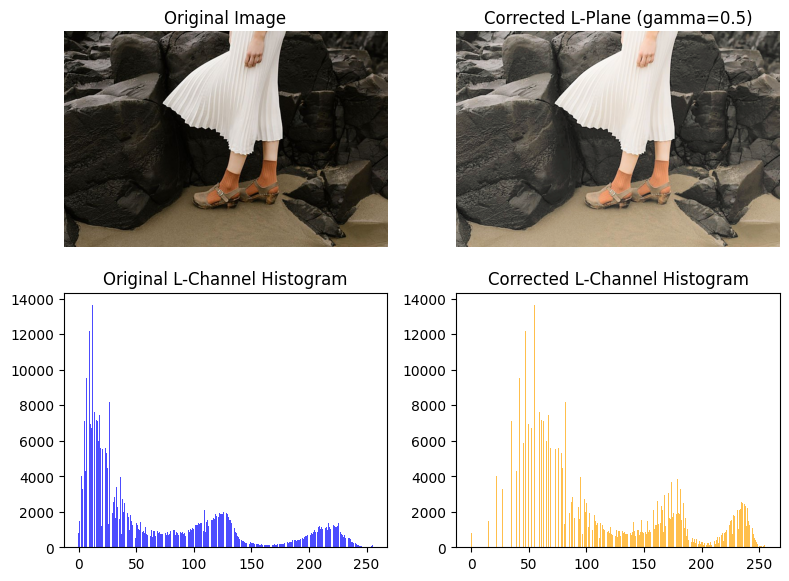

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread('images/a1images/highlights_and_shadows.jpg')
assert im is not None, 'Image not found'

im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)

l_channel, a, b = cv.split(im_lab)

gamma = 0.5
l_gamma = np.array(255 * (l_channel / 255) ** gamma, dtype=np.uint8)

lab_corrected = cv.merge([l_gamma, a, b])
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].imshow(im_rgb)
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(img_corrected)
ax[0, 1].set_title(f'Corrected L-Plane (gamma={gamma})')
ax[0, 1].axis('off')

hist_l_channel = cv.calcHist([l_channel], [0], None, [256], [0, 256]).flatten()
ax[1, 0].bar(range(256), hist_l_channel, color='blue', alpha=0.7)
ax[1, 0].set_title('Original L-Channel Histogram')

hist_l_gamma = cv.calcHist([l_gamma], [0], None, [256], [0, 256]).flatten()
ax[1, 1].bar(range(256), hist_l_gamma, color='orange', alpha=0.7)
ax[1, 1].set_title('Corrected L-Channel Histogram')

plt.tight_layout()
plt.show()